## D2D Example: CLD on Sleep and Depressive symptoms in Young Adults
In this example, we  implement a system dynamics model (SDM) analysis of a causal loop diagram (CLD) by Uleman et al (2025) Submitted. This CLD focuses on the reinforcing feedback loops between sleep and depressive symptoms in young adults.

In Kumu, the diagram looks as follows:

<img src="YAMH CLD.jpg" alt="drawing" width="600"/>

To analyze this CLD, we will first imports the settings and the Kumu file. We will then run the simulations with what-if scenarios, assess the intervention effects, and then perform sensitivity analysis over the model parameters.

In [1]:
import os
from systemdynamics.cld import Extract
from systemdynamics.sdm import SDM
from systemdynamics.plots import plot_simulated_intervention_ranking

current_path = os.getcwd()  # Select current path
file_name = "YAMH"  # Specify the relevant name of the CLD Excel file
file_path = os.path.join(current_path, f"{file_name}.xlsx")

extract = Extract(file_path)  # Load the relevant Kumu file extraction module
s = extract.extract_settings()  # Extract the settings using the Kumu Excel file

# Set simulation settings
s.seed = 1912884
s.N = 200  # Number of simulations
s.t_end = 12  # Timeframe of the simulation
s.time_unit = "Months"  # Base unit of time (time unit of t_end and dt)
s.prior = "uniform"  # "uniform" or "halfnormal"
s.parameter_value_aux = 0.1
s.parameter_value_stocks = 0.1

sdm = SDM(s)  # Load the module for formulating and simulating the SDM

Variables of interest: ['Sleep disturbance', 'Depressive symptoms']
with 21 intervention variables

1971 feedback loops of maximum length 5
All loops have at least one stock
No interaction terms specified so will solve linear SDM.


Given these settings, we can now run simulations from the SDM-converted CLD.

In [2]:
df_sol, param_samples = sdm.run_simulations()  # Run the simulated interventions
intervention_effects_per_voi = sdm.get_intervention_effects()  # Get the intervention effects

Running Simulations:  72%|███████▎  | 145/200 [00:48<00:21,  2.58it/s]

Running Simulations: 100%|██████████| 200/200 [01:09<00:00,  2.89it/s]


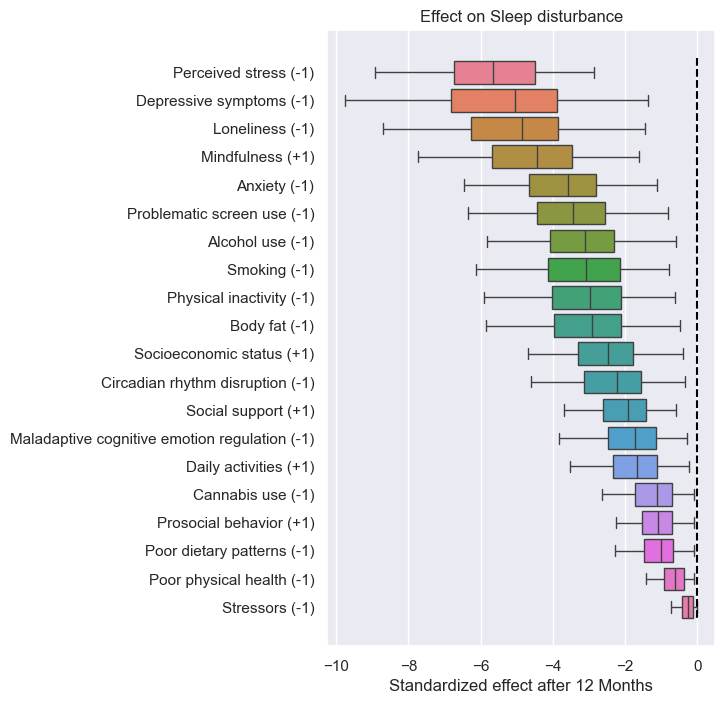

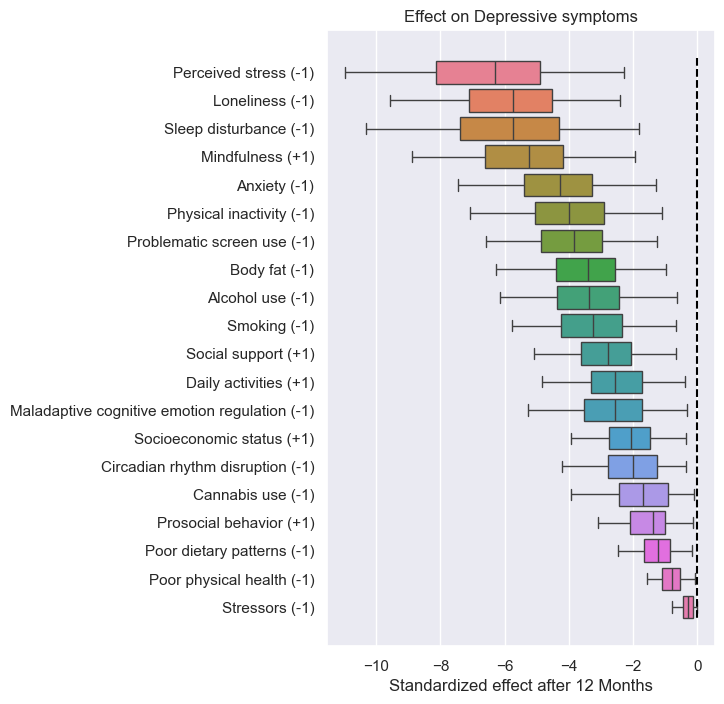

In [3]:
for voi in s.variable_of_interest:
    plot_simulated_intervention_ranking(s, intervention_effects_per_voi[voi], 
                                        voi, top_plot=None, order=None);  # Plot the simulated interventions ranking


In [4]:
## Intervention effects table
for voi in s.variable_of_interest:
    print("---- Variable of Interest: ", voi)
    sdm.compare_interventions_table(intervention_effects_per_voi[voi])  # Print the table of the simulated interventions
    print("")

---- Variable of Interest:  Sleep disturbance

Comparison Table (Percentage Greater, 95% CI, Cliff’s Delta):
+------------------------------------------+------------------------------------------+-------------+----------------------+-----------------+
| Intervention A                           | Intervention B                           |   % Greater | 95% CI (% Greater)   |   Cliff's Delta |
+==========================================+==========================================+=============+======================+=================+
| Perceived stress                         | Sleep disturbance                        |        48.5 | [41.0, 55.0]         |           -0.03 |
+------------------------------------------+------------------------------------------+-------------+----------------------+-----------------+
| Perceived stress                         | Depressive symptoms                      |        63.5 | [57.5, 71.0]         |            0.27 |
+--------------------------------

## Sensitivity analysis

In [ ]:
## Estimate spearman correlation for the model parameters, either for one intervention variable (int_var) or for all
cut_off_SA_importance = 0.1
int_var = None  # If None, the simulations of all intervention will be used

for voi in s.variable_of_interest:
    print("---- Variable of Interest: ", voi)
    outcome_var = voi  # If None, all variables will be used to assess change in the model
    SA_results, df_SA = sdm.run_SA(outcome_var, int_var, cut_off_SA_importance)
    print("")

---- Variable of Interest:  Sleep disturbance
